# Plots

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

- Generate Pareto frontier plots using GPU and CPU evaluation data.

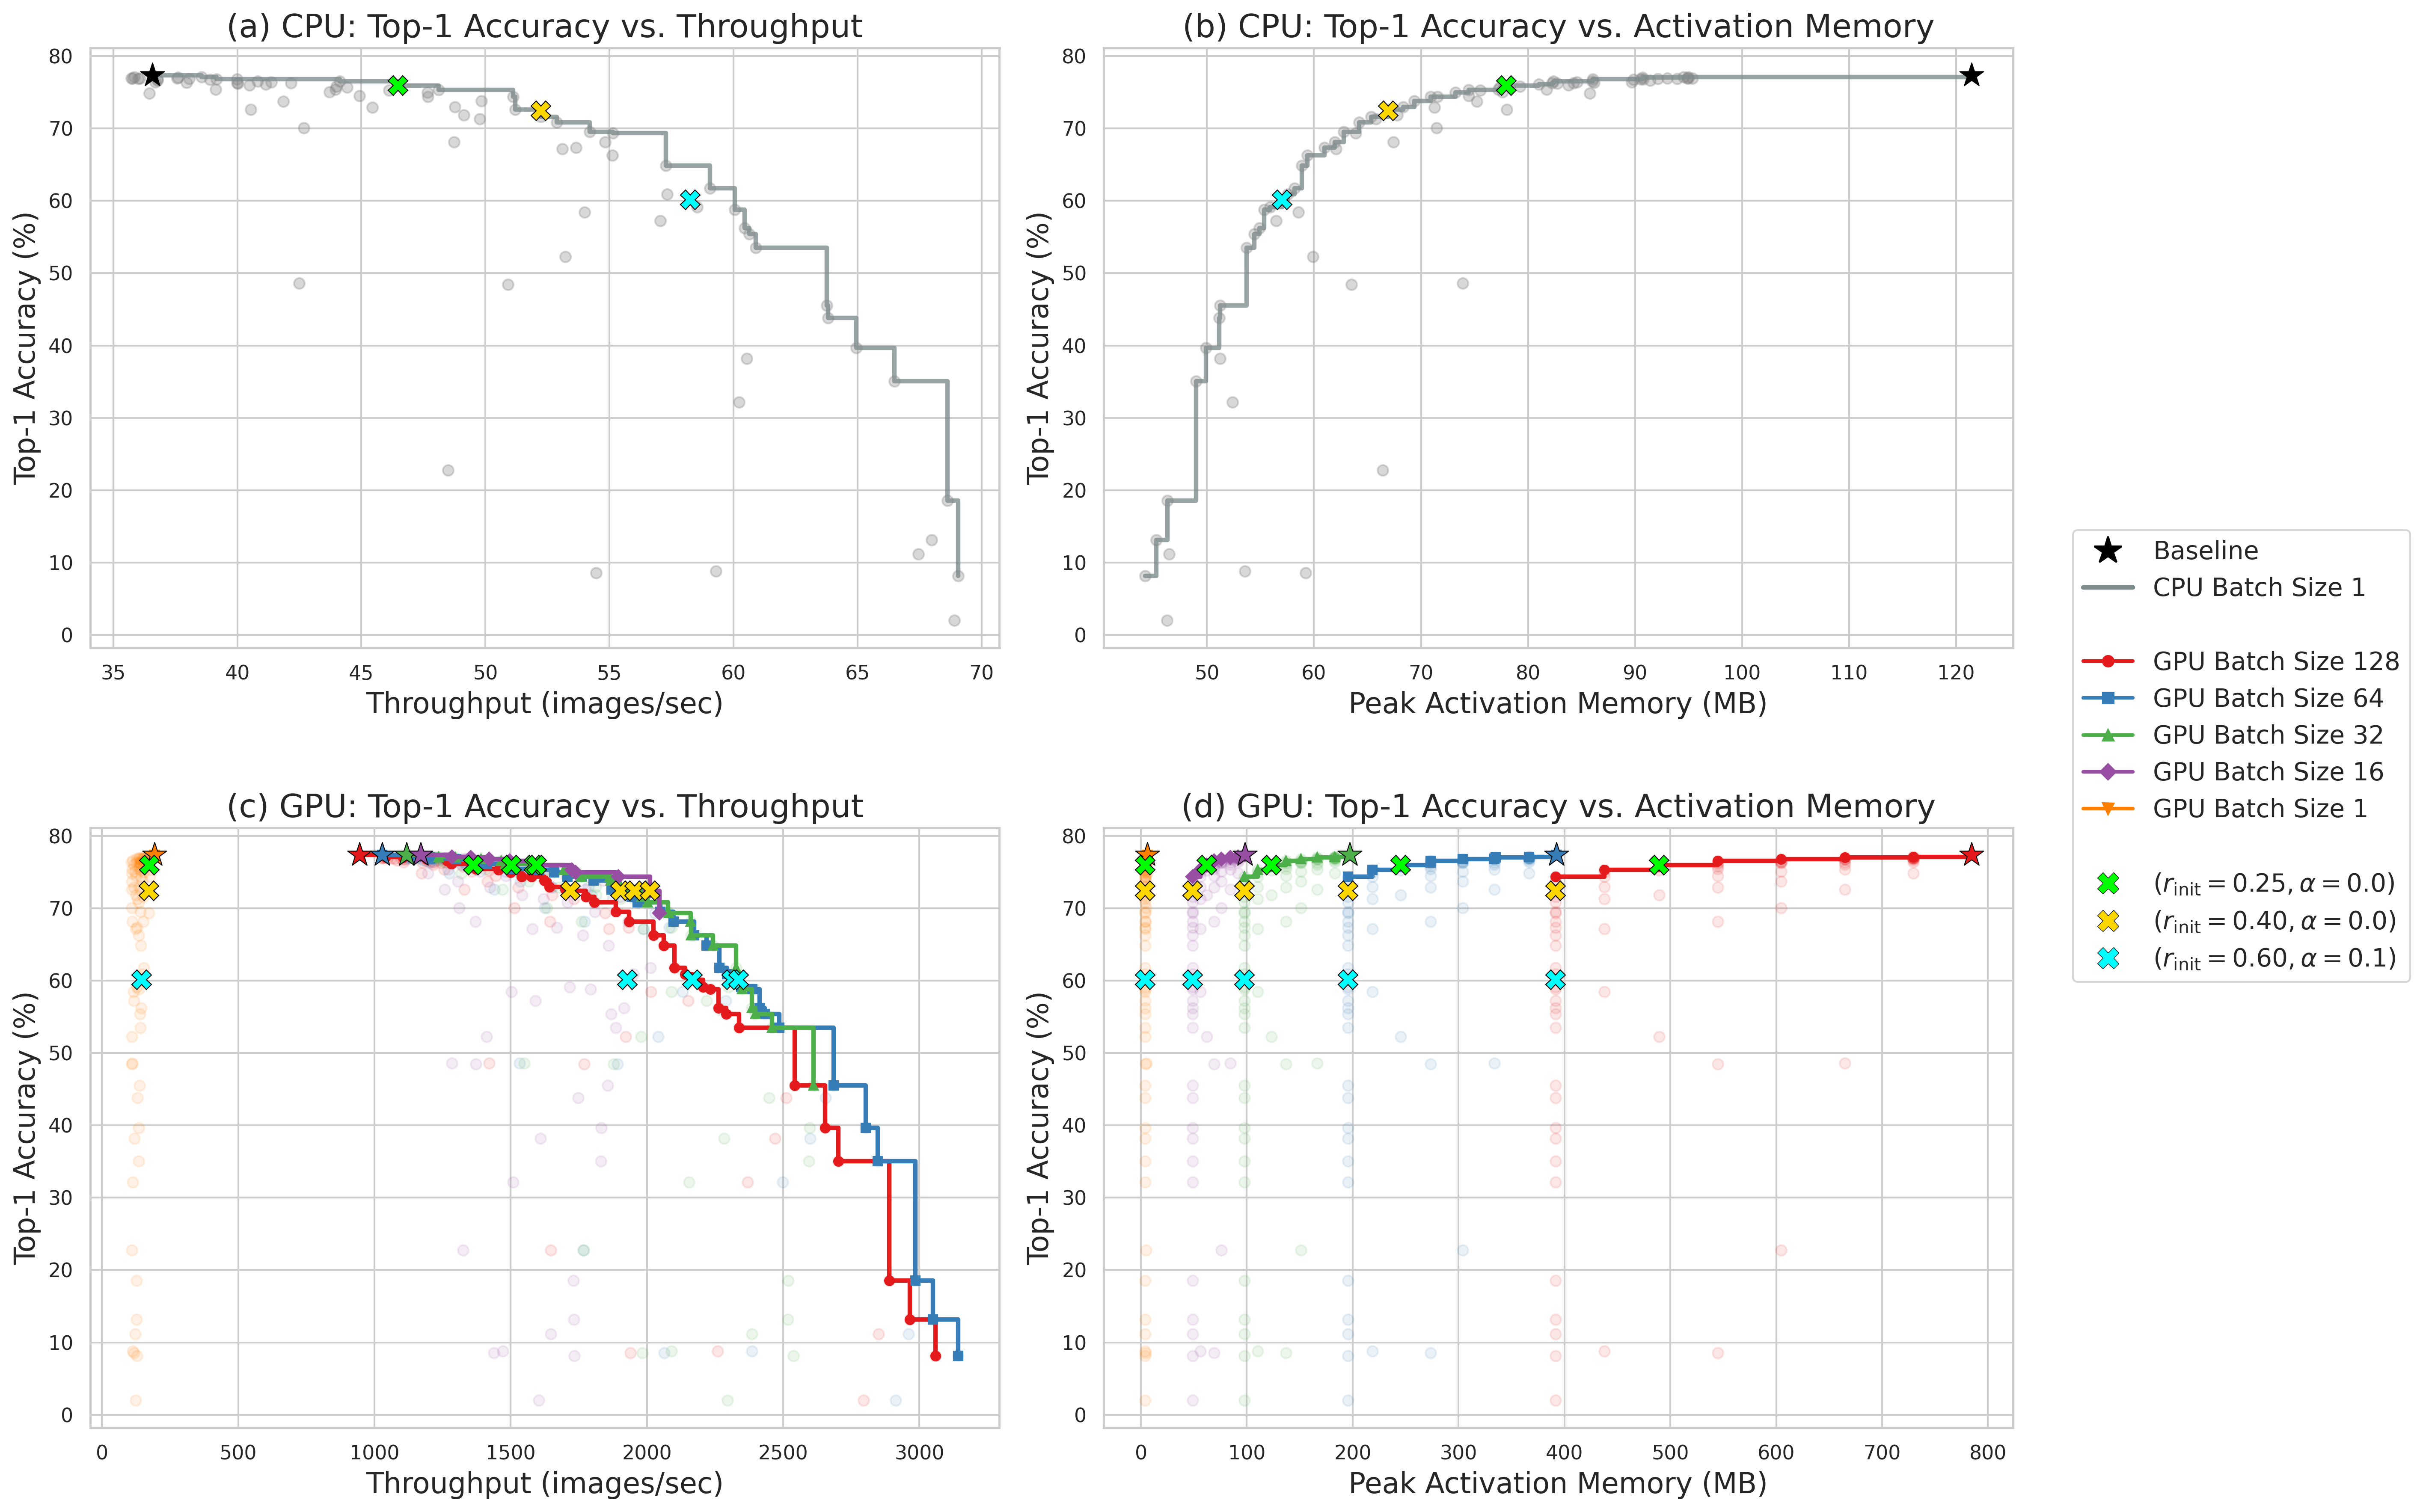

In [2]:
def get_pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    """
    Calculates the Pareto optimal coordinates for plotting.

     Args:
        Xs: list of X-axis values.
        Ys: list of Y-axis values.
        maxX: whether to maximize X values.
        maxY: whether to maximize Y values.
    
    Returns:
        tuple: the Pareto frontier as lists of ordered Xs and Ys.
    """
    points = list(zip(Xs, Ys))
    # sort based on x-value or y-value
    points.sort(key=lambda p: (-p[0] if maxX else p[0], -p[1] if maxY else p[1]))
    
    # sweep the frontier
    pareto_front = [points[0]]
    for point in points[1:]:
        if maxY:
            if point[1] > pareto_front[-1][1]:
                pareto_front.append(point)
        else:
            if point[1] < pareto_front[-1][1]:
                pareto_front.append(point)
    
    # return as unziped lists
    return [p[0] for p in pareto_front], [p[1] for p in pareto_front]


# ! prepare data

# load data
df_cpu = pd.read_csv('grid_search_cpu.csv')
df_gpu = pd.read_csv('grid_search_gpu.csv')

# remove 'failed' rows
df_cpu = df_cpu.replace('FAILED', pd.NA).dropna()
df_gpu = df_gpu.replace('FAILED', pd.NA).dropna()

# convert to numeric
df_cpu = df_cpu.apply(pd.to_numeric)
df_gpu = df_gpu.apply(pd.to_numeric)

# merge datasets
merged = pd.merge(df_cpu, df_gpu, on=['initial_r_ratio', 'alpha'])

baseline = merged[(merged['initial_r_ratio'] == 0.0) & (merged['alpha'] == 1.0)]
targets = [
    {'name': r'($r_{\text{init}}=0.25, \alpha=0.0$)', 'r': 0.25, 'a': 0.0, 'color': 'lime', 'marker': 'X'},
    {'name': r'($r_{\text{init}}=0.40, \alpha=0.0$)', 'r': 0.40, 'a': 0.0, 'color': 'gold', 'marker': 'X'},
    {'name': r'($r_{\text{init}}=0.60, \alpha=0.1$)', 'r': 0.60, 'a': 0.1, 'color': 'aqua', 'marker': 'X'}
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 14,            
    'axes.labelsize': 16,       
    'axes.titlesize': 18,       
    'legend.fontsize': 14,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

batch_sizes = [128, 64, 32, 16, 1]
colors = sns.color_palette("Set1", n_colors=len(batch_sizes))
markers = ['o', 's', '^', 'D', 'v']

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
ax_cpu_tp  = axs[0, 0]
ax_cpu_pam = axs[0, 1]
ax_gpu_tp  = axs[1, 0]
ax_gpu_pam = axs[1, 1]


# ! cpu : acc vs tp

Xs, Ys = merged['throughput'].values, merged['accuracy'].values
pX, pY = get_pareto_frontier(Xs, Ys, maxX=True, maxY=True)

ax_cpu_tp.scatter(Xs, Ys, color='gray', alpha=0.3, zorder=2)
ax_cpu_tp.step(pX, pY, where='pre', color='#7f8c8d', linestyle='-', alpha=0.8, zorder=3, label='CPU Pareto Frontier')
ax_cpu_tp.scatter(baseline['throughput'].values, baseline['accuracy'].values, color='black', marker='*', s=200, edgecolor='black', linewidths=0.5, zorder=5)

for t in targets:
    row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
    ax_cpu_tp.plot(row.iloc[0]['throughput'], row.iloc[0]['accuracy'], marker=t['marker'], color=t['color'], markersize=11, markeredgecolor='black', markeredgewidth=0.5, zorder=10)

ax_cpu_tp.set_title('(a) CPU: Top-1 Accuracy vs. Throughput')
ax_cpu_tp.set_xlabel('Throughput (images/sec)')
ax_cpu_tp.set_ylabel('Top-1 Accuracy (%)')


# ! cpu : acc vs pam

Xs, Ys = merged['activation_ram_MB'].values, merged['accuracy'].values
pX, pY = get_pareto_frontier(Xs, Ys, maxX=False, maxY=True)

ax_cpu_pam.scatter(Xs, Ys, color='gray', alpha=0.3, zorder=2)
ax_cpu_pam.step(pX, pY, where='post', color='#7f8c8d', linestyle='-', alpha=0.8, zorder=3)
ax_cpu_pam.scatter(baseline['activation_ram_MB'].values, baseline['accuracy'].values, color='black', marker='*', s=200, edgecolor='black', linewidths=0.5, zorder=5)

for t in targets:
    row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
    ax_cpu_pam.plot(row.iloc[0]['activation_ram_MB'], row.iloc[0]['accuracy'], marker=t['marker'], color=t['color'], markersize=11, markeredgecolor='black', markeredgewidth=0.5, zorder=10)

ax_cpu_pam.set_title('(b) CPU: Top-1 Accuracy vs. Activation Memory')
ax_cpu_pam.set_xlabel('Peak Activation Memory (MB)')
ax_cpu_pam.set_ylabel('Top-1 Accuracy (%)')


# ! gpu : acc vs tp

for i, bs in enumerate(batch_sizes):
    col_name = f'throughput_bs{bs}'
    Xs, Ys = merged[col_name].values, merged['accuracy'].values
    pX, pY = get_pareto_frontier(Xs, Ys, maxX=True, maxY=True)
    
    ax_gpu_tp.scatter(Xs, Ys, color=colors[i], alpha=0.1, zorder=2)
    ax_gpu_tp.step(pX, pY, where='pre', color=colors[i], marker=markers[i], ms=5, linestyle='-', zorder=3, label=f'BS={bs}')
    ax_gpu_tp.scatter(baseline[col_name].values, baseline['accuracy'].values, color=colors[i], marker='*', s=200, edgecolor='black', linewidths=0.5, zorder=5)

    for t in targets:
        row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
        ax_gpu_tp.plot(row.iloc[0][col_name], row.iloc[0]['accuracy'], marker=t['marker'], color=t['color'], markersize=11, markeredgecolor='black', markeredgewidth=0.5, zorder=10)

ax_gpu_tp.set_title('(c) GPU: Top-1 Accuracy vs. Throughput')
ax_gpu_tp.set_xlabel('Throughput (images/sec)')
ax_gpu_tp.set_ylabel('Top-1 Accuracy (%)')


# ! gpu : acc vs pam

for i, bs in enumerate(batch_sizes):
    col_name = f'activation_mem_bs{bs}'
    Xs, Ys = merged[col_name].values, merged['accuracy'].values
    pX, pY = get_pareto_frontier(Xs, Ys, maxX=False, maxY=True)
    
    ax_gpu_pam.scatter(Xs, Ys, color=colors[i], alpha=0.1, zorder=2)
    ax_gpu_pam.step(pX, pY, where='post', color=colors[i], marker=markers[i], ms=5, linestyle='-', zorder=3)
    ax_gpu_pam.scatter(baseline[col_name].values, baseline['accuracy'].values, color=colors[i], marker='*', s=200, edgecolor='black', linewidths=0.5, zorder=5)

    for t in targets:
        row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
        ax_gpu_pam.plot(row.iloc[0][col_name], row.iloc[0]['accuracy'], marker=t['marker'], color=t['color'], markersize=11, markeredgecolor='black', markeredgewidth=0.5, zorder=10)

ax_gpu_pam.set_title('(d) GPU: Top-1 Accuracy vs. Activation Memory')
ax_gpu_pam.set_xlabel('Peak Activation Memory (MB)')
ax_gpu_pam.set_ylabel('Top-1 Accuracy (%)')


# ! combine
legend_elements = [
    Line2D([0], [0], color='w', marker='*', markerfacecolor='black', markeredgecolor='black', markersize=16, label='Baseline'),
    Line2D([0], [0], color='#7f8c8d', linestyle='-', linewidth=2.5, label='CPU Batch Size 1'),
    Line2D([0], [0], color='w', label=''), # spacer
]

for i, bs in enumerate(batch_sizes):
    legend_elements.append(Line2D([0], [0], color=colors[i], marker=markers[i], linestyle='-', linewidth=2, label=f'GPU Batch Size {bs}'))

legend_elements.append(Line2D([0], [0], color='w', label='')) # spacer

for t in targets:
    legend_elements.append(Line2D([0], [0], color='w', marker=t['marker'], markerfacecolor=t['color'], markeredgecolor='black', markersize=12, markeredgewidth=0.3, label=t['name']))

fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)
fig.savefig('plots/pareto.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

- Generate token count tracking plots.

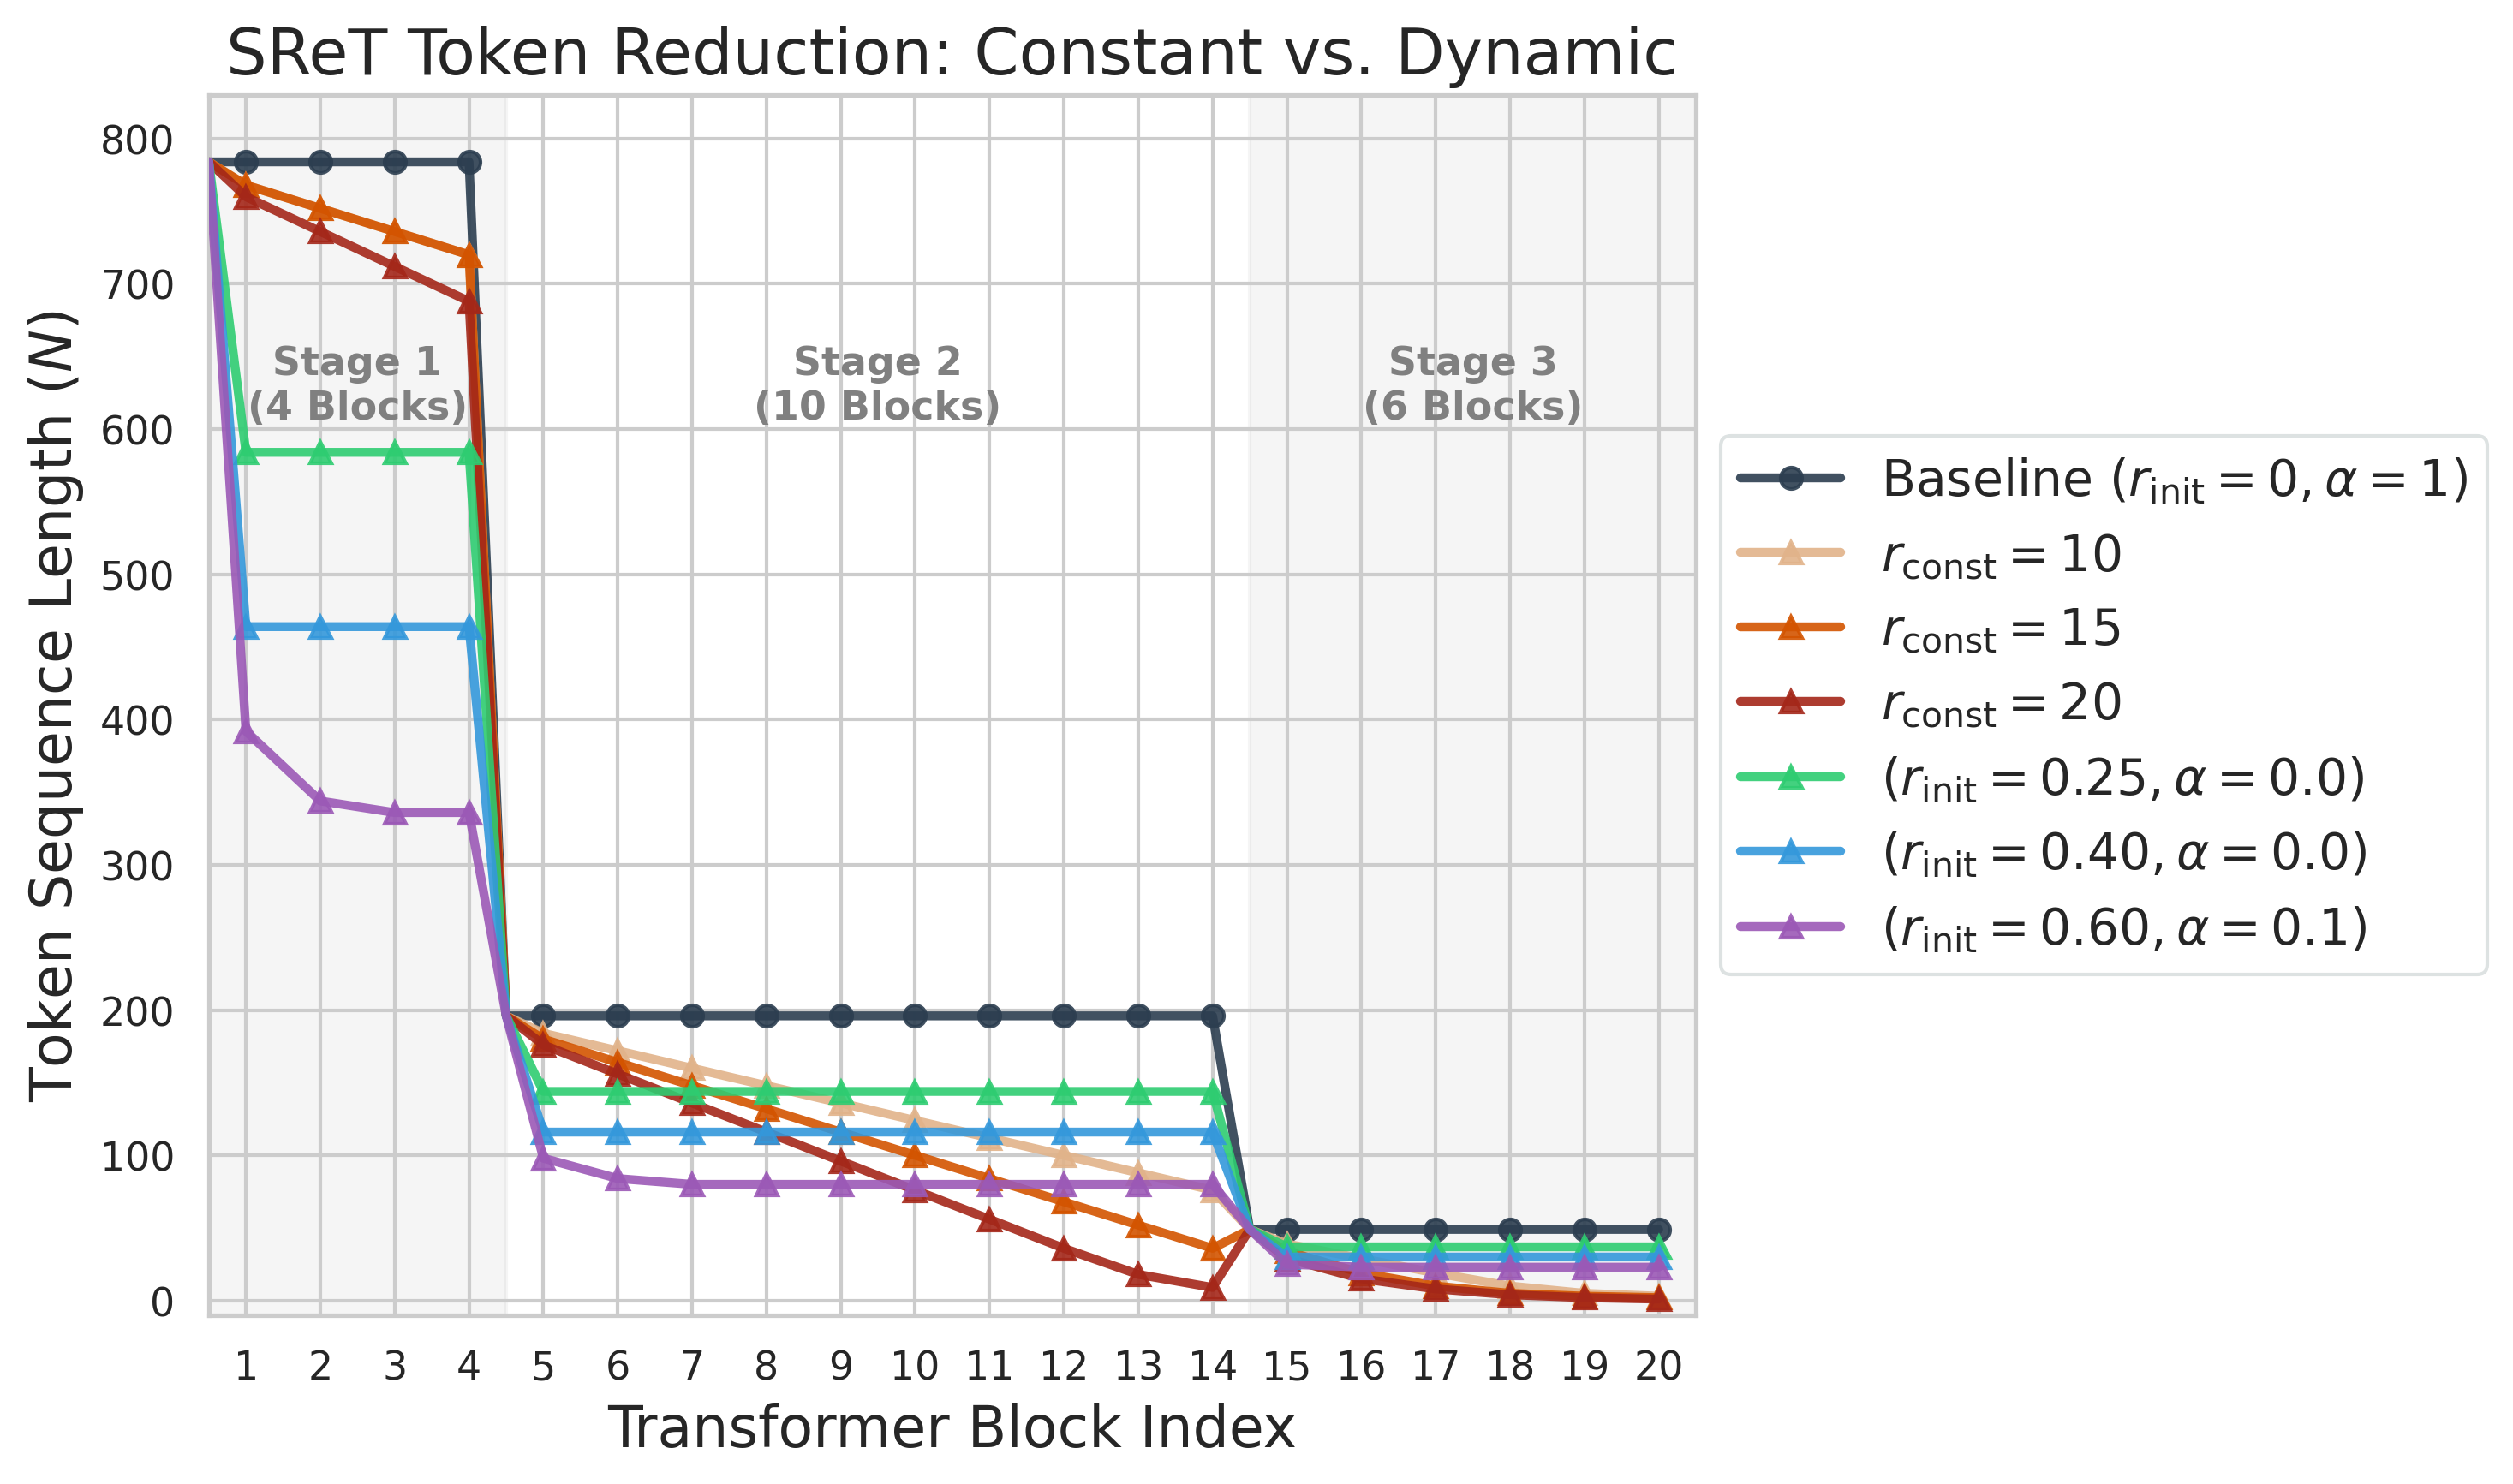

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 14,            
    'axes.labelsize': 16,       
    'axes.titlesize': 18,       
    'legend.fontsize': 14,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

x_coords = [0.5, 1, 2, 3, 4, 4.5, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 14.5, 15, 16, 17, 18, 19, 20]

sret_token_progression = {
    "Baseline ($r_{\\text{init}}=0, \\alpha=1$)": [
        784, # stage 1 base
        784, 784, 784, 784, 
        196, # stage 2 base
        196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 
        49,  # stage 3 base
        49, 49, 49, 49, 49, 49
    ],
    "$r_{\\text{const}}=10$": [
        784, # stage 1 base
        768, 752, 736, 720, 
        196, # stage 2 base
        184, 172, 160, 148, 136, 124, 112, 100, 88, 76, 
        49,  # stage 3 base
        39, 29, 19, 10, 5, 3
    ],
    "$r_{\\text{const}}=15$": [
        784, # stage 1 base
        768, 752, 736, 720, 
        196, # stage 2 base
        180, 164, 148, 132, 116, 100, 84, 68, 52, 36, 
        49,  # stage 3 base
        34, 19, 10, 5, 3, 2
    ],
    "$r_{\\text{const}}=20$": [
        784, # stage 1 base
        760, 736, 712, 688, 
        196, # stage 2 base
        176, 156, 136, 116, 96, 76, 56, 36, 18, 9, 
        49,  # stage 3 base
        29, 15, 8, 4, 2, 1
    ],
    "($r_{\\text{init}}=0.25, \\alpha=0.0$)": [
        784, # stage 1 base
        584, 584, 584, 584, 
        196, # stage 2 base
        144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 
        49,  # stage 3 base
        37, 37, 37, 37, 37, 37
    ],
    "($r_{\\text{init}}=0.40, \\alpha=0.0$)": [
        784, # stage 1 base
        464, 464, 464, 464, 
        196, # stage 2 base
        116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 
        49,  # stage 3 base
        30, 30, 30, 30, 30, 30
    ],
    "($r_{\\text{init}}=0.60, \\alpha=0.1$)": [
        784, # stage 1 base
        392, 344, 336, 336, 
        196, # stage 2 base
        98, 84, 80, 80, 80, 80, 80, 80, 80, 80, 
        49,  # stage 3 base
        25, 23, 23, 23, 23, 23
    ]
}

colors = {
    "Baseline ($r_{\\text{init}}=0, \\alpha=1$)": "#2c3e50",      
    "$r_{\\text{const}}=10$": "#e1b38a",               
    "$r_{\\text{const}}=15$": "#d35400",               
    "$r_{\\text{const}}=20$": "#a42719",               
    "($r_{\\text{init}}=0.25, \\alpha=0.0$)": "#2ecc71",
    "($r_{\\text{init}}=0.40, \\alpha=0.0$)": "#3498db",
    "($r_{\\text{init}}=0.60, \\alpha=0.1$)": "#9b59b6" 
}

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvspan(0.5, 4.5, color='gray', alpha=0.08, zorder=0)
ax.axvspan(4.5, 14.5, color='white', alpha=0.0, zorder=0)
ax.axvspan(14.5, 20.5, color='gray', alpha=0.08, zorder=0)

block_marker_indices = [i for i, x in enumerate(x_coords) if x % 1 == 0]

for label, tokens in sret_token_progression.items():
    if "Constant" in label:
        linestyle = '--'
        marker = 's'  # square
    elif "Baseline" in label:
        linestyle = '-'
        marker = 'o'  # circle
    else:
        linestyle = '-'
        marker = '^'  # triangle
        
    ax.plot(x_coords, tokens, label=label, color=colors[label], linestyle=linestyle, marker=marker, markersize=6, markevery=block_marker_indices, alpha=0.9, zorder=5)

ax.text(2.5, 630, 'Stage 1\n(4 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')
ax.text(9.5, 630, 'Stage 2\n(10 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')
ax.text(17.5, 630, 'Stage 3\n(6 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')

ax.set_title('SReT Token Reduction: Constant vs. Dynamic')
ax.set_xlabel('Transformer Block Index')
ax.set_ylabel('Token Sequence Length ($N$)')
ax.set_xticks(range(1, 21))
ax.set_xlim(0.5, 20.5)
ax.set_ylim(-10, 830)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, facecolor='white', edgecolor='#d5dbdb')
fig.tight_layout()
fig.savefig('plots/sret_token_count.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

- Generate plot for showing impact of decay rate (alpha).

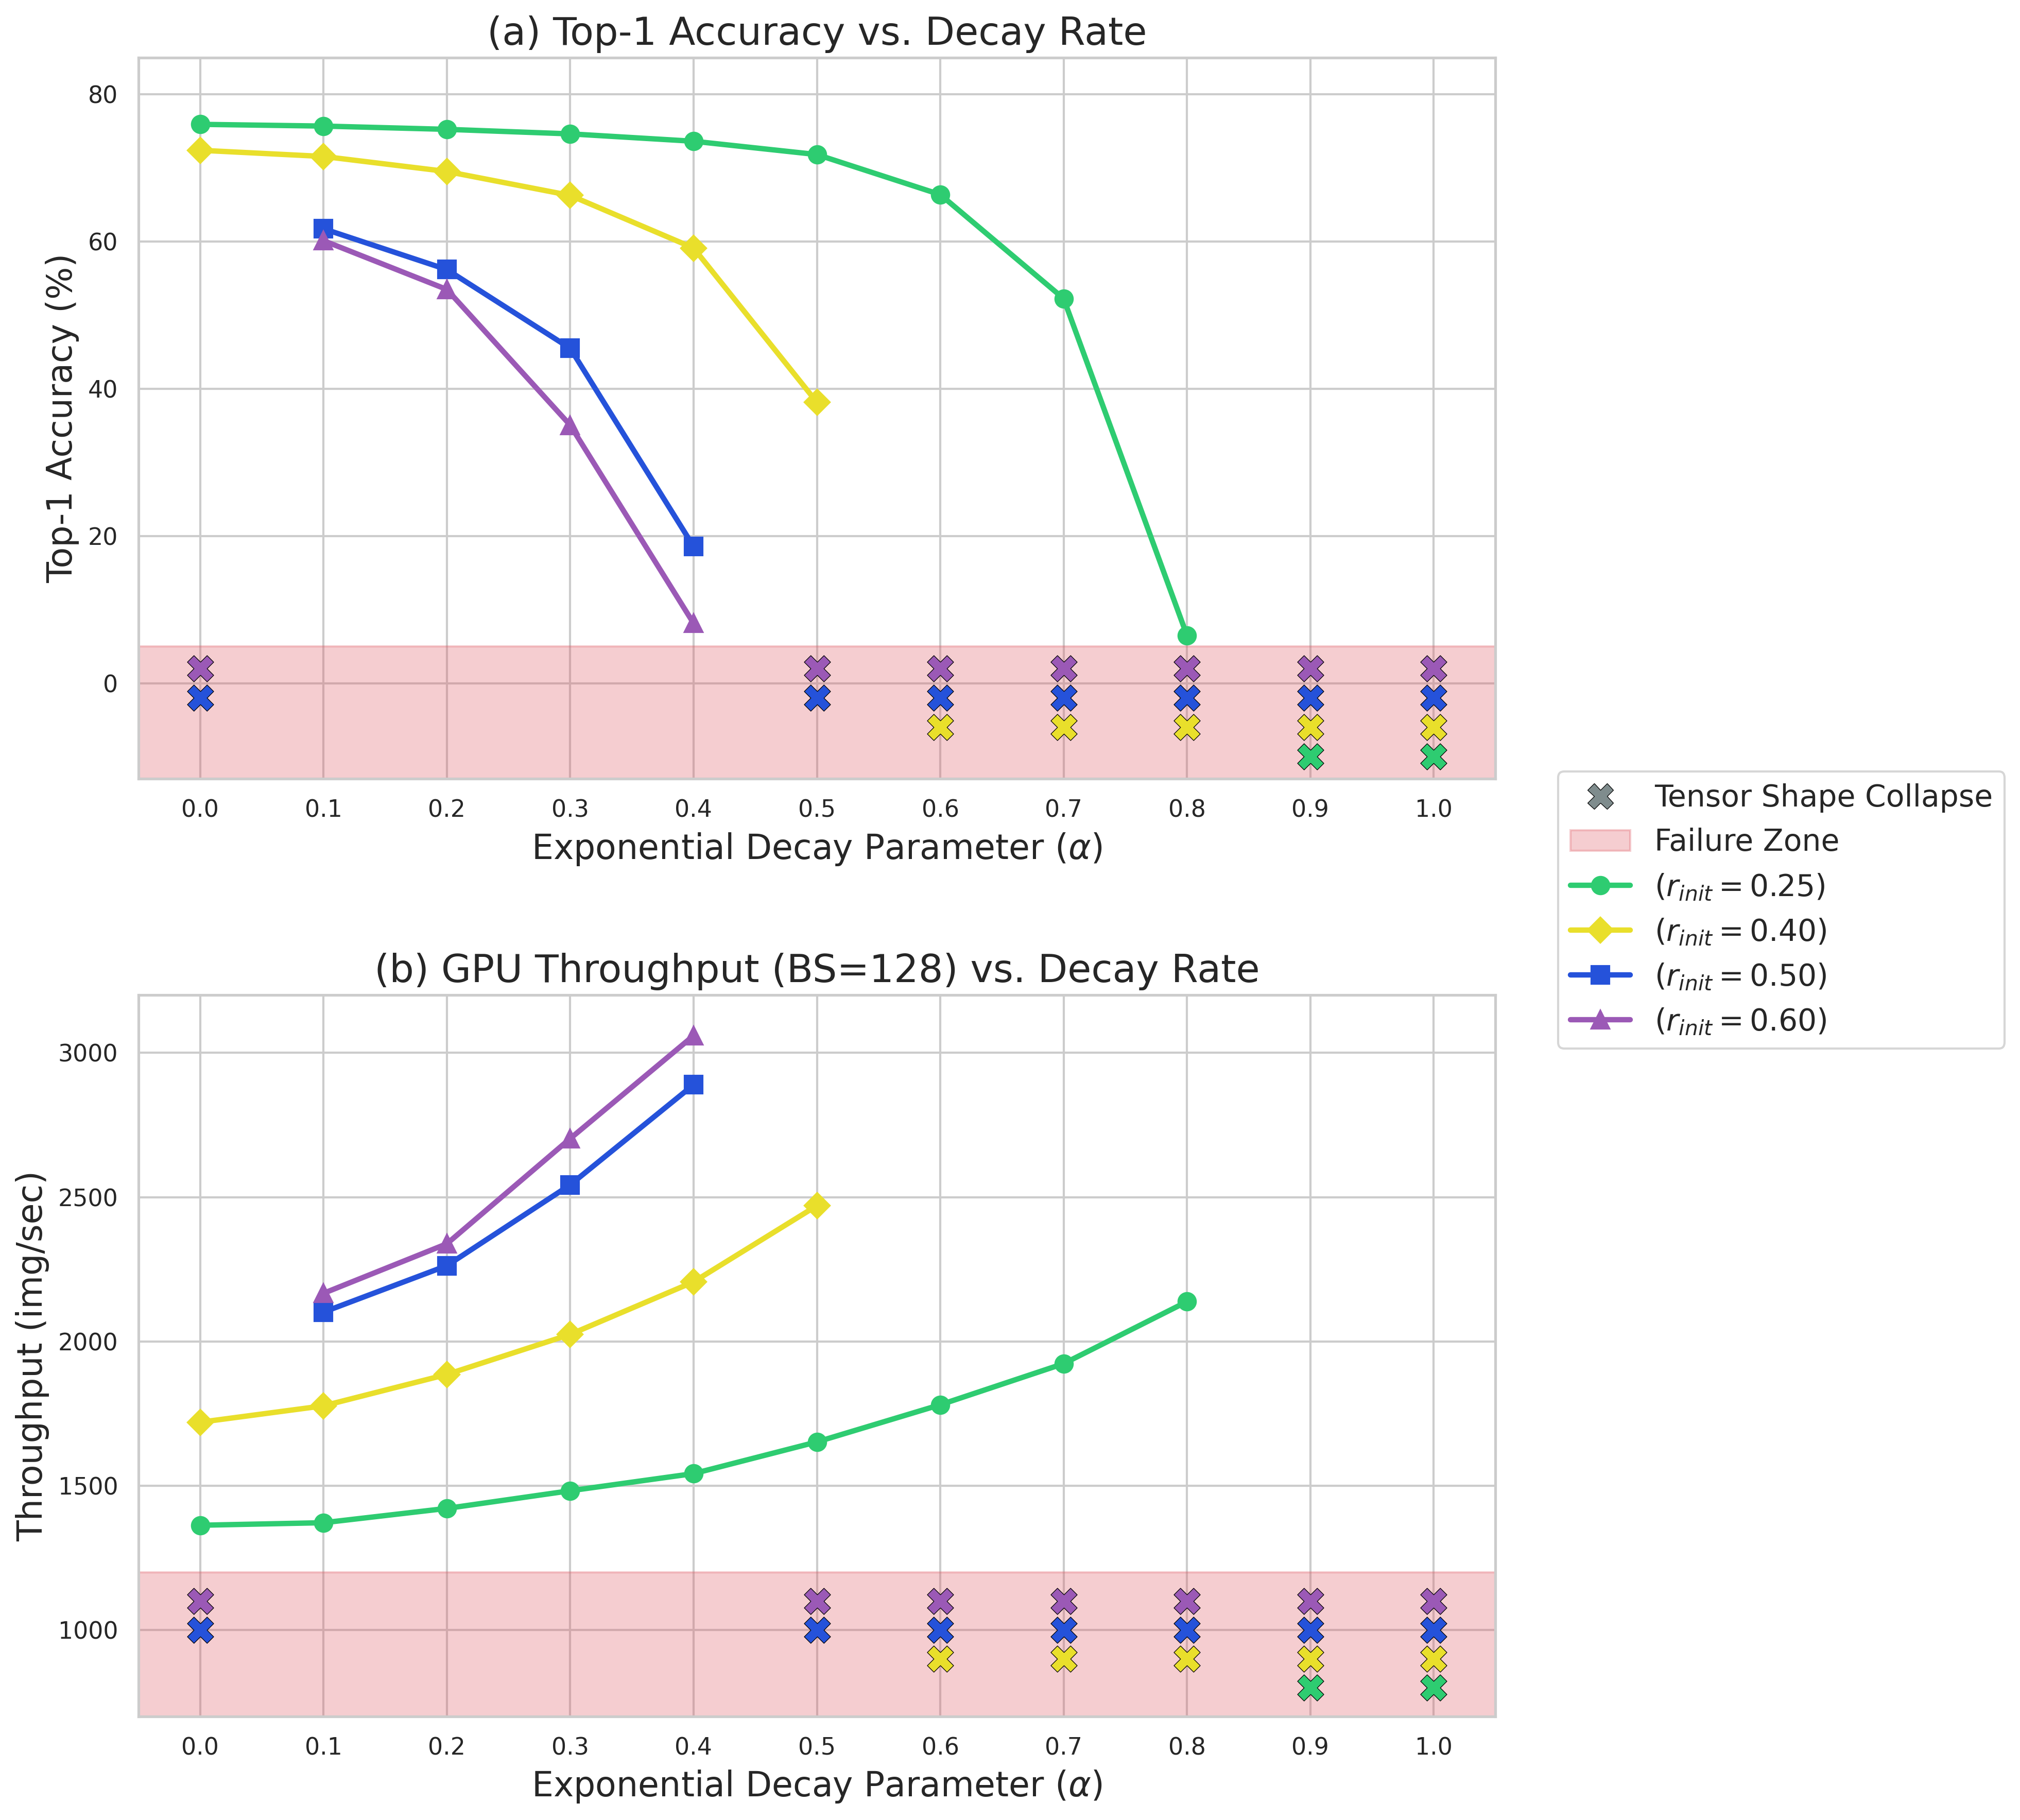

In [4]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 14,            
    'axes.labelsize': 16,       
    'axes.titlesize': 18,       
    'legend.fontsize': 14,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

df_gpu = pd.read_csv('grid_search_gpu.csv')
alphas = np.arange(0.0, 1.1, 0.1)

def get_series_data(r_val):
    accs = []
    tps = []
    status = []
    for a in alphas:
        row = df_gpu[(np.isclose(df_gpu['initial_r_ratio'], r_val)) & (np.isclose(df_gpu['alpha'], a))]
        if row.empty:
            accs.append(np.nan)
            tps.append(np.nan)
            status.append('FAILED')
        else:
            val = row['accuracy'].values[0]
            if val == 'FAILED':
                accs.append(np.nan)
                tps.append(np.nan)
                status.append('FAILED')
            else:
                accs.append(float(val))
                tps.append(float(row['throughput_bs128'].values[0]))
                status.append('SUCCESS')
    return np.array(accs), np.array(tps), status

acc_r25, tp_r25, status_r25 = get_series_data(0.25)
acc_r40, tp_r40, status_r40 = get_series_data(0.40)
acc_r50, tp_r50, status_r50 = get_series_data(0.50)
acc_r60, tp_r60, status_r60 = get_series_data(0.60)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# ! acc plot
ax1.axhspan(-13, 5, color="#DF5A65", alpha=0.3, label='Failure Zone', zorder=1)

ax1.plot(alphas, acc_r25, label='($r_{init}=0.25$)', color='#2ecc71', marker='o', markersize=8, zorder=3)
ax1.plot(alphas, acc_r40, label='($r_{init}=0.40$)', color="#e9df2b", marker='D', markersize=8, zorder=3)
ax1.plot(alphas, acc_r50, label='($r_{init}=0.50$)', color="#2552da", marker='s', markersize=8, zorder=3)
ax1.plot(alphas, acc_r60, label='($r_{init}=0.60$)', color='#9b59b6', marker='^', markersize=8, zorder=3)

# show x markers
for i, a in enumerate(alphas):
    if status_r25[i] == 'FAILED': ax1.scatter(a, -10, color='#2ecc71', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r40[i] == 'FAILED': ax1.scatter(a, -6,  color='#e9df2b', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r50[i] == 'FAILED': ax1.scatter(a, -2,  color='#2552da', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r60[i] == 'FAILED': ax1.scatter(a, 2,   color='#9b59b6', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)

ax1.set_title('(a) Top-1 Accuracy vs. Decay Rate')
ax1.set_xlabel('Exponential Decay Parameter ($\\alpha$)')
ax1.set_ylabel('Top-1 Accuracy (%)')
ax1.set_xticks(alphas)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-13, 85)

# ! throughput plot
ax2.axhspan(500, 1200, color="#DF5A65", alpha=0.3, label='Failure Zone', zorder=1)

ax2.plot(alphas, tp_r25, color='#2ecc71', marker='o', markersize=8, zorder=3)
ax2.plot(alphas, tp_r40, color="#e9df2b", marker='D', markersize=8, zorder=3)
ax2.plot(alphas, tp_r50, color="#2552da", marker='s', markersize=8, zorder=3)
ax2.plot(alphas, tp_r60, color='#9b59b6', marker='^', markersize=8, zorder=3)

# show x markers
for i, a in enumerate(alphas):
    if status_r25[i] == 'FAILED': ax2.scatter(a, 800, color='#2ecc71', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r40[i] == 'FAILED': ax2.scatter(a, 900, color='#e9df2b', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r50[i] == 'FAILED': ax2.scatter(a, 1000,    color='#2552da', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)
    if status_r60[i] == 'FAILED': ax2.scatter(a, 1100,  color='#9b59b6', marker='X', s=150, edgecolor='black', linewidth=0.3, zorder=4)

ax2.set_title('(b) GPU Throughput (BS=128) vs. Decay Rate')
ax2.set_xlabel('Exponential Decay Parameter ($\\alpha$)')
ax2.set_ylabel('Throughput (img/sec)')
ax2.set_xticks(alphas)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(700, 3200)

handles, labels = ax1.get_legend_handles_labels()
failure_marker = Line2D([0], [0], marker='X', color='w', markerfacecolor='#7f8c8d', markeredgecolor='black', markersize=12, markeredgewidth=0.3, label='Tensor Shape Collapse')

handles.insert(0, failure_marker)
labels.insert(0, 'Tensor Shape Collapse')

unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in unique_labels:
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)
fig.savefig('plots/decay_rate.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)